In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('insurance.csv')

In [ ]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.shape

(1338, 7)

In [ ]:
df.columns

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [ ]:
df.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


In [ ]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [ ]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [ ]:
print(df['sex'].unique())
print(df['smoker'].unique())
print(df['region'].unique())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']


In [ ]:
df.duplicated().sum()

np.int64(1)

In [ ]:
df[df.duplicated()]

,age,sex,bmi,children,smoker,region,charges
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
df[df.duplicated(keep=False)]

,age,sex,bmi,children,smoker,region,charges
195,19,male,30.59,0,no,northwest,1639.5631
581,19,male,30.59,0,no,northwest,1639.5631


In [ ]:
df=df.drop_duplicates()

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print("Dataset Size:",df.shape)

Dataset Size: (1337, 7)


In [ ]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


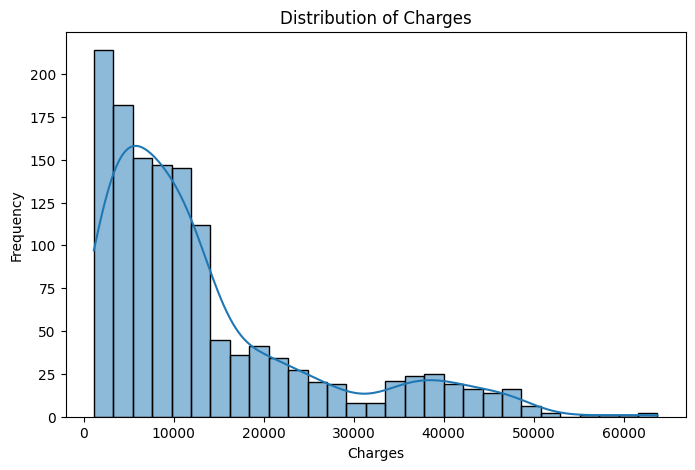

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['charges'],kde=True)

plt.title('Distribution of Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')

plt.show()

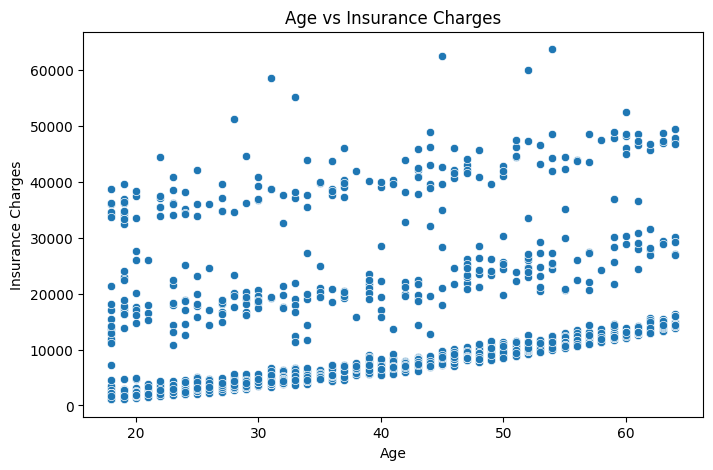

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['age'],
    y=df['charges']
)

plt.title('Age vs Insurance Charges')
plt.xlabel('Age')
plt.ylabel('Insurance Charges')

plt.show()

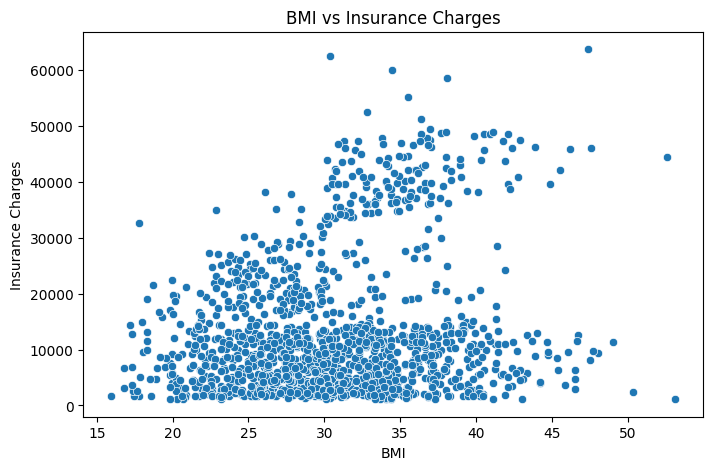

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['bmi'],
    y=df['charges']
)

plt.title('BMI vs Insurance Charges')
plt.xlabel('BMI')
plt.ylabel('Insurance Charges')

plt.show()

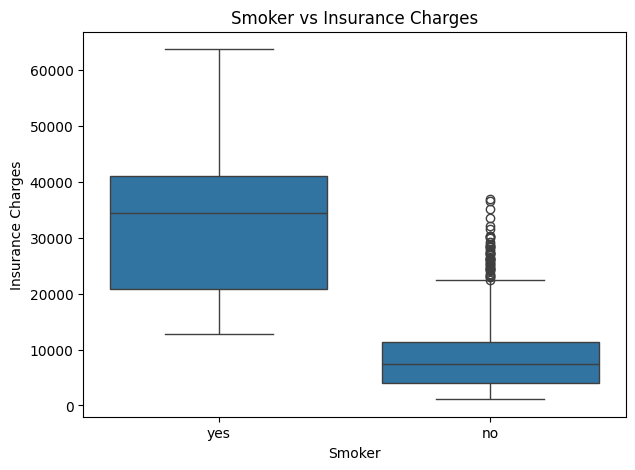

In [ ]:
plt.figure(figsize=(7,5))

sns.boxplot(
    x=df['smoker'],
    y=df['charges']
)

plt.title('Smoker vs Insurance Charges')
plt.xlabel('Smoker')
plt.ylabel('Insurance Charges')

plt.show()

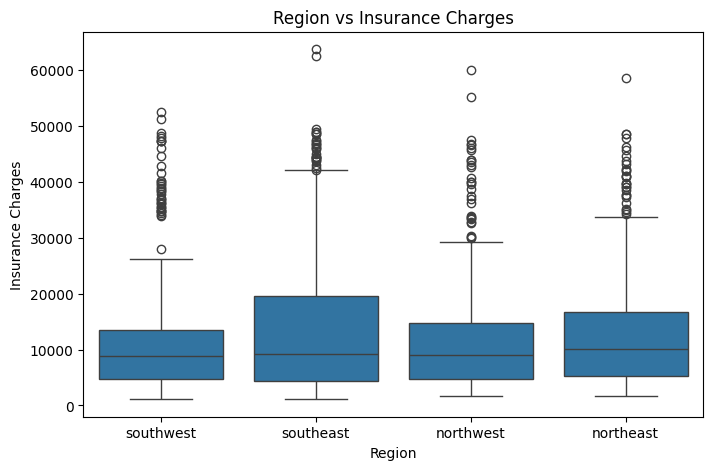

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['region'],
    y=df['charges']
)

plt.title('Region vs Insurance Charges')
plt.xlabel('Region')
plt.ylabel('Insurance Charges')

plt.show()

In [ ]:
correlation = df.select_dtypes(include='number').corr()

print(correlation)

               age       bmi  children   charges
age       1.000000  0.109344  0.041536  0.298308
bmi       0.109344  1.000000  0.012755  0.198401
children  0.041536  0.012755  1.000000  0.067389
charges   0.298308  0.198401  0.067389  1.000000


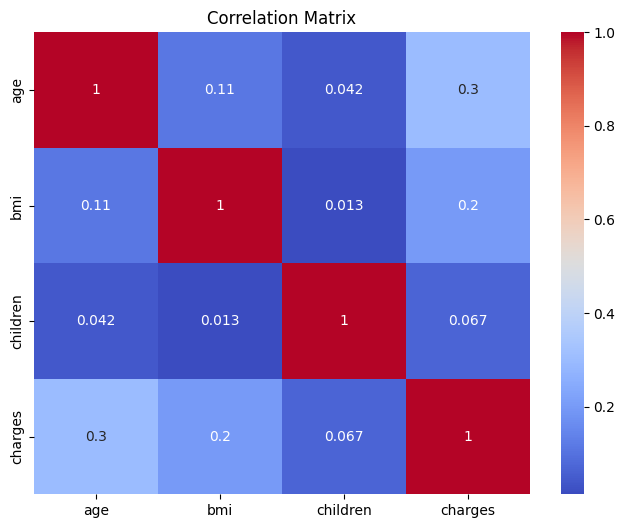

In [ ]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Matrix')

plt.show()

In [ ]:
X=df.drop('charges',axis=1)
Y=df['charges']

In [ ]:
print('X columns:')
print(X.columns)

print("\n y column:")
print(Y.name)

X columns:
Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region'], dtype='object')

 y column:
charges


In [ ]:
print(X.dtypes)

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
dtype: object


In [ ]:
X = pd.get_dummies(X, drop_first=True)

In [ ]:
print(X.dtypes)

age                   int64
bmi                 float64
children              int64
sex_male               bool
smoker_yes             bool
region_northwest       bool
region_southeast       bool
region_southwest       bool
dtype: object


In [ ]:
print(X.isnull().sum())

age                 0
bmi                 0
children            0
sex_male            0
smoker_yes          0
region_northwest    0
region_southeast    0
region_southwest    0
dtype: int64


In [ ]:
print(Y.isnull().sum())

0


In [ ]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1337, 8)
y shape: (1337,)


In [ ]:
X = X.astype(int)

In [ ]:
print(X.dtypes)

age                 int64
bmi                 int64
children            int64
sex_male            int64
smoker_yes          int64
region_northwest    int64
region_southeast    int64
region_southwest    int64
dtype: object


In [ ]:
X = df.drop('charges', axis=1)

X = pd.get_dummies(X, drop_first=True)

# Convert only boolean columns to 0/1
bool_columns = X.select_dtypes(include='bool').columns
X[bool_columns] = X[bool_columns].astype(int)

y = df['charges']

In [ ]:
print(X.dtypes)

age                   int64
bmi                 float64
children              int64
sex_male              int64
smoker_yes            int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object


In [ ]:
print(X.head())
print(X.dtypes)

   age     bmi  children  sex_male  smoker_yes  region_northwest  \
0   19  27.900         0         0           1                 0   
1   18  33.770         1         1           0                 0   
2   28  33.000         3         1           0                 0   
3   33  22.705         0         1           0                 1   
4   32  28.880         0         1           0                 1   

   region_southeast  region_southwest  
0                 0                 1  
1                 1                 0  
2                 1                 0  
3                 0                 0  
4                 0                 0  
age                   int64
bmi                 float64
children              int64
sex_male              int64
smoker_yes            int64
region_northwest      int64
region_southeast      int64
region_southwest      int64
dtype: object


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1069, 8)
X_test : (268, 8)
y_train: (1069,)
y_test : (268,)


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()

In [ ]:
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
print("Coefficients:")
print(model.coef_)

Coefficients:
[  248.21072022   318.70144095   533.0099888   -101.54205399
 23077.76459287  -391.76145478  -838.91961573  -659.13975155]


In [ ]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)

            Feature   Coefficient
0               age    248.210720
1               bmi    318.701441
2          children    533.009989
3          sex_male   -101.542054
4        smoker_yes  23077.764593
5  region_northwest   -391.761455
6  region_southeast   -838.919616
7  region_southwest   -659.139752


In [ ]:
print("Intercept:", model.intercept_)

Intercept: -11092.65229594595


In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
comparison = pd.DataFrame({
    'Actual Charges': y_test.values,
    'Predicted Charges': y_pred
})

print(comparison.head(10))

   Actual Charges  Predicted Charges
0      8688.85885        8143.693884
1      5708.86700        5737.115683
2     11436.73815       14369.314876
3     38746.35510       31745.513636
4      4463.20510        8962.386657
5      9304.70190       13149.722353
6     38511.62830       30446.760679
7      2150.46900        1453.288813
8      7345.72660       10633.018402
9     10264.44210       11318.943794


In [ ]:
print("Number of predictions:", len(y_pred))

Number of predictions: 268


In [ ]:
print("Actual:", y_test.iloc[0])
print("Predicted:", y_pred[0])

Actual: 8688.85885
Predicted: 8143.693884116448


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np


In [ ]:
r2 = r2_score(y_test, y_pred)

print("R2 Score:", r2)

R2 Score: 0.8069287081198011


In [ ]:
mae = mean_absolute_error(y_test, y_pred)

print("Mean Absolute Error:", mae)

Mean Absolute Error: 4177.045561036319


In [ ]:
mse = mean_squared_error(y_test, y_pred)

print("Mean Squared Error:", mse)

Mean Squared Error: 35478020.67523561


In [ ]:
rmse = np.sqrt(mse)

print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 5956.342894363588


In [ ]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print("Training R2:", train_r2)
print("Testing R2 :", test_r2)

Training R2: 0.7299057809339075
Testing R2 : 0.8069287081198011


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

# Predictions
y_pred = model.predict(X_test)

# Evaluation
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

print("========== MODEL EVALUATION ==========")
print("R2 Score :", r2)
print("MAE      :", mae)
print("MSE      :", mse)
print("RMSE     :", rmse)

========== MODEL EVALUATION ==========
R2 Score : 0.8069287081198011
MAE      : 4177.045561036319
MSE      : 35478020.67523561
RMSE     : 5956.342894363588


In [ ]:
train_r2 = model.score(X_train, y_train)
test_r2 = model.score(X_test, y_test)

print("Training R2:", train_r2)
print("Testing R2 :", test_r2)

Training R2: 0.7299057809339075
Testing R2 : 0.8069287081198011


In [ ]:
import pickle

with open("MedicalInsuranceModel.pkl", "wb") as file:
    pickle.dump(model, file)

print("Model saved successfully!")

Model saved successfully!


In [ ]:
import os

print(os.path.exists("MedicalInsuranceModel.pkl"))

True
